In [1]:
import pandas as pd

df = pd.read_csv("employee_data.csv")

print(df.head())
print(df.shape)

  EmpID   Name Department   Age  Experience   Salary
0   E01  Aarav         IT  28.0         4.0  45000.0
1   E02   Sita         HR  35.0         9.0  52000.0
2   E03  Bibek    Finance   NaN         6.0  48000.0
3   E04  Anita         IT  41.0        15.0  70000.0
4   E05  Rajan  Marketing  30.0         5.0      NaN
(15, 6)


## Q1. Creating a DataFrame

In [2]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("employee_data.csv")

# Display shape
print("Shape of DataFrame:")
print(df.shape)

# Display first five rows
print("\nFirst Five Rows:")
print(df.head())

# Display information about the DataFrame
print("\nDataFrame Information:")
df.info()

Shape of DataFrame:
(15, 6)

First Five Rows:
  EmpID   Name Department   Age  Experience   Salary
0   E01  Aarav         IT  28.0         4.0  45000.0
1   E02   Sita         HR  35.0         9.0  52000.0
2   E03  Bibek    Finance   NaN         6.0  48000.0
3   E04  Anita         IT  41.0        15.0  70000.0
4   E05  Rajan  Marketing  30.0         5.0      NaN

DataFrame Information:
<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   EmpID       15 non-null     str    
 1   Name        15 non-null     str    
 2   Department  14 non-null     str    
 3   Age         14 non-null     float64
 4   Experience  14 non-null     float64
 5   Salary      14 non-null     float64
dtypes: float64(3), str(3)
memory usage: 852.0 bytes


## Q2. Finding Missing Values and Duplicate Rows

In [3]:
# Count missing values in each column
print("Missing Values Per Column:")
print(df.isnull().sum())

# Count duplicate rows
print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

# Display duplicate rows
print("\nDuplicate Rows:")
print(df[df.duplicated()])

Missing Values Per Column:
EmpID         0
Name          0
Department    1
Age           1
Experience    1
Salary        1
dtype: int64

Number of Duplicate Rows:
2

Duplicate Rows:
   EmpID   Name Department   Age  Experience   Salary
12   E04  Anita         IT  41.0        15.0  70000.0
14   E06   Puja         HR  26.0         2.0  38000.0


## Q3. Imputing Missing Values

In [4]:
# Create a copy of the dataset
df_imputed = df.copy()

# Fill numeric columns with median
df_imputed["Age"] = df_imputed["Age"].fillna(df_imputed["Age"].median())
df_imputed["Experience"] = df_imputed["Experience"].fillna(df_imputed["Experience"].median())
df_imputed["Salary"] = df_imputed["Salary"].fillna(df_imputed["Salary"].median())

# Fill categorical column with mode
df_imputed["Department"] = df_imputed["Department"].fillna(
    df_imputed["Department"].mode()[0]
)

# Verify missing values
print(df_imputed.isnull().sum())

EmpID         0
Name          0
Department    0
Age           0
Experience    0
Salary        0
dtype: int64


## Q4. Cleaning Wrong Data

In [5]:
# Create a copy of the imputed dataset
clean_df = df_imputed.copy()

# Step 1: Remove duplicate rows
before = clean_df.shape[0]
clean_df = clean_df.drop_duplicates()

print("Duplicates Removed:", before - clean_df.shape[0])

# Step 2: Handle Age outlier
# Keep ages between 18 and 60
clean_df = clean_df[(clean_df["Age"] >= 18) & (clean_df["Age"] <= 60)]

# Step 3: Detect and remove Salary outliers using IQR

Q1 = clean_df["Salary"].quantile(0.25)
Q3 = clean_df["Salary"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Remove outliers
clean_df = clean_df[
    (clean_df["Salary"] >= lower_bound) &
    (clean_df["Salary"] <= upper_bound)
]

# Final shape
print("Final Shape:", clean_df.shape)

Duplicates Removed: 2
Lower Bound: 24375.0
Upper Bound: 77375.0
Final Shape: (11, 6)


## Q5 – Standardization

In [7]:
from sklearn.preprocessing import StandardScaler

# Create a copy of cleaned dataset
std_df = clean_df.copy()

# Columns to standardize
cols = ["Age", "Experience", "Salary"]

# Initialize scaler
scaler = StandardScaler()

# Apply standardization
std_df[cols] = scaler.fit_transform(std_df[cols])

# Display first 5 rows
print(std_df.head())

  EmpID   Name Department       Age  Experience    Salary
0   E01  Aarav         IT -0.791146   -0.758989 -0.584918
1   E02   Sita         HR  0.452084    0.223232  0.153421
2   E03  Bibek    Finance -0.080729   -0.366101 -0.268487
3   E04  Anita         IT  1.517709    1.401897  2.052009
4   E05  Rajan  Marketing -0.435938   -0.562545  0.047944


In [8]:
print(std_df[["Age","Experience","Salary"]].mean())
print(std_df[["Age","Experience","Salary"]].std())

Age           2.220446e-16
Experience    8.074349e-17
Salary        1.413011e-16
dtype: float64
Age           1.048809
Experience    1.048809
Salary        1.048809
dtype: float64


## Q6 – Data Transformation 

(a) Apply a log transformation to Salary using np.log1p() and store it in a new column Salary_Log to reduce skewness.

In [9]:
import numpy as np

transform_df = clean_df.copy()

# Log transformation
transform_df["Salary_Log"] = np.log1p(transform_df["Salary"])

print(transform_df[["Salary", "Salary_Log"]].head())

    Salary  Salary_Log
0  45000.0   10.714440
1  52000.0   10.859018
2  48000.0   10.778977
3  70000.0   11.156265
4  51000.0   10.839601


(b) Encode the Department column into numeric codes (label encoding).


In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

transform_df["Department_Code"] = le.fit_transform(
    transform_df["Department"]
)

print(transform_df[["Department", "Department_Code"]].head())

  Department  Department_Code
0         IT                2
1         HR                1
2    Finance                0
3         IT                2
4  Marketing                3


(c) Create an Age_Group column by binning Age into Young (<30), Mid (30–45) and
Senior (>45).

In [11]:
def age_group(age):
    if age < 30:
        return "Young"
    elif age <= 45:
        return "Mid"
    else:
        return "Senior"

transform_df["Age_Group"] = transform_df["Age"].apply(age_group)

print(transform_df[["Age", "Age_Group"]].head())

    Age Age_Group
0  28.0     Young
1  35.0       Mid
2  32.0       Mid
3  41.0       Mid
4  30.0       Mid


## Q7 – Histogram of Age

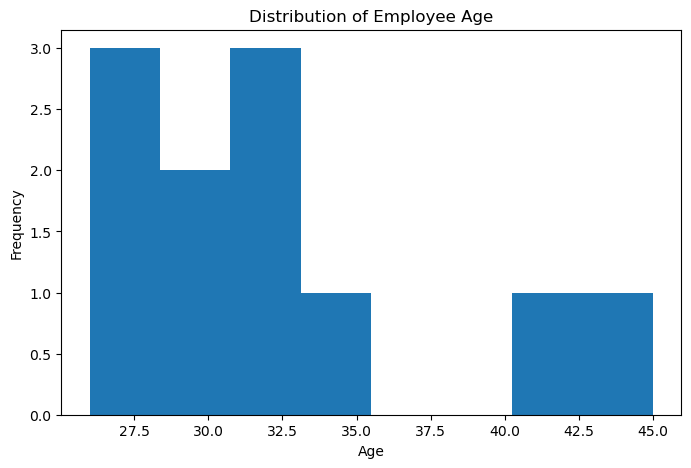

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(clean_df["Age"], bins=8)

plt.title("Distribution of Employee Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

## Q8. Box Plot of Salary Before and After Outlier Removal

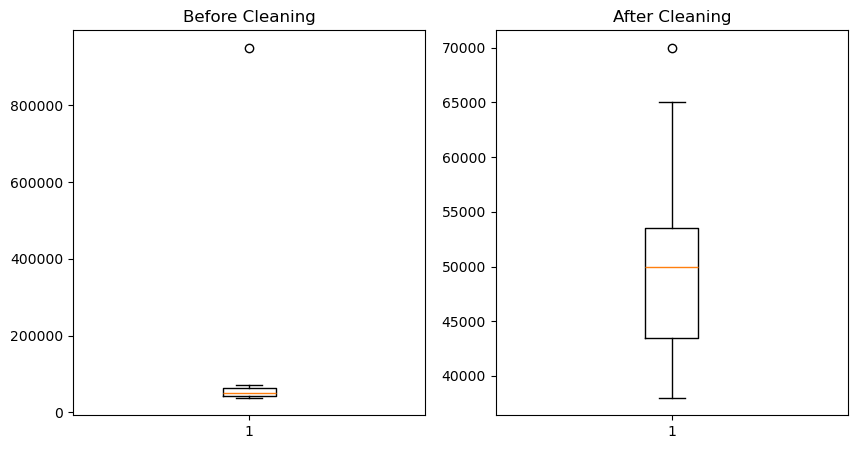

In [14]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.boxplot(df_imputed["Salary"])
plt.title("Before Cleaning")

plt.subplot(1,2,2)
plt.boxplot(clean_df["Salary"])
plt.title("After Cleaning")

plt.show()

## Q9. Count Plot (Department-wise Employee Count)

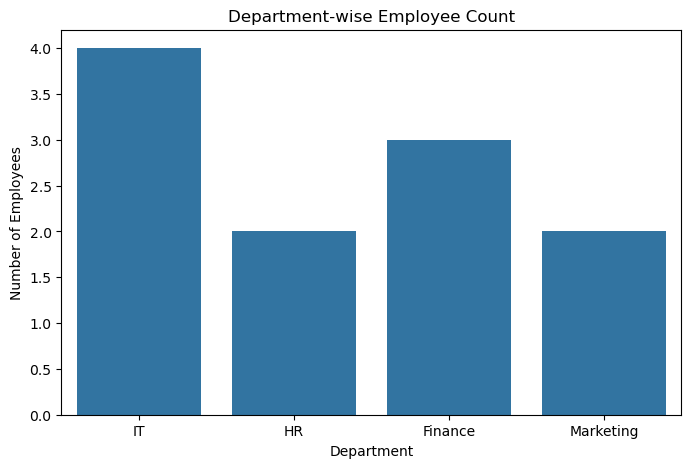

In [15]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x="Department", data=clean_df)

plt.title("Department-wise Employee Count")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.show()

## Q10. Scatter Plot: Experience vs Salary

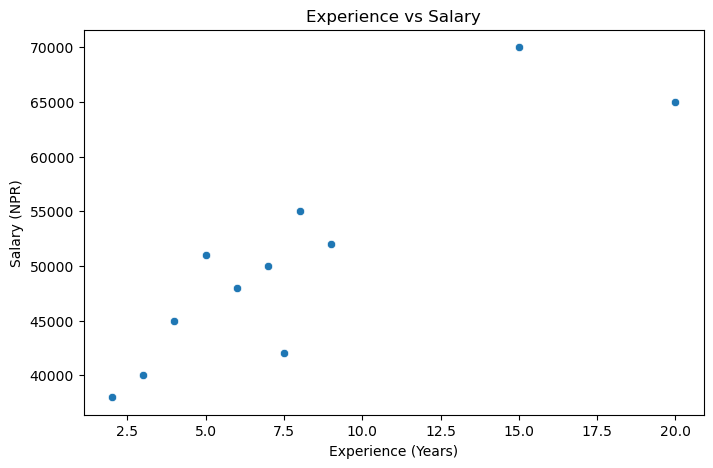

In [18]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Experience",
    y="Salary",
    data=clean_df
)

plt.title("Experience vs Salary")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary (NPR)")

plt.show()